In [1]:
# ============================================================
# 0. INSTALL PACKAGES
# ============================================================

!pip uninstall -y community -q
!pip install -q numpy pandas networkx scikit-learn tqdm python-louvain GraphRicciCurvature scipy
!pip install -q igraph leidenalg


# ============================================================
# 1. IMPORTS AND CONFIG
# ============================================================

import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

import community_detection_utils as cdu


RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("./data/amazon")
DATA_DIR.mkdir(parents=True, exist_ok=True)

EDGES_FILE = DATA_DIR / "com-amazon.ungraph.txt.gz"
CMTY_FILE = DATA_DIR / "com-amazon.top5000.cmty.txt.gz"

EDGE_URL = (
    "https://snap.stanford.edu/data/bigdata/communities/"
    "com-amazon.ungraph.txt.gz"
)

CMTY_URL = (
    "https://snap.stanford.edu/data/bigdata/communities/"
    "com-amazon.top5000.cmty.txt.gz"
)

MIN_COMMUNITY_SIZE = 20

MIN_COMPONENT_NODES = 80
MAX_COMPONENT_NODES = 500
MIN_LABELS = 4
MAX_LABELS = 25

LRC_ONLY_PCT = 20
LRC_COMBO_PCT = 5
ORC_COMBO_PCT = 5

ALPHA = 0.5
ORC_ITERATIONS = 5

SEEDS = [0, 1, 2, 3, 4]


# ============================================================
# 2. DOWNLOAD DATA
# ============================================================

cdu.download_if_missing(
    EDGE_URL,
    EDGES_FILE
)

cdu.download_if_missing(
    CMTY_URL,
    CMTY_FILE
)


# ============================================================
# 3. LOAD GRAPH AND COMMUNITIES
# ============================================================

G_full = nx.Graph()

for chunk in tqdm(
    cdu.stream_edges(EDGES_FILE),
    desc="Loading Amazon graph"
):
    G_full.add_edges_from(
        chunk[["u", "v"]].itertuples(
            index=False,
            name=None
        )
    )

G_full.remove_edges_from(
    nx.selfloop_edges(G_full)
)

communities = cdu.load_communities(
    CMTY_FILE,
    min_size=1
)

print(G_full)
print("Total communities:", len(communities))

print(
    pd.Series(
        [len(community) for community in communities]
    ).describe()
)


# ============================================================
# 4. COMMUNITY STRUCTURAL METRICS
# ============================================================

rows = []

for cid, nodes in tqdm(
    list(enumerate(communities)),
    desc="Computing community metrics"
):
    if len(nodes) < MIN_COMMUNITY_SIZE:
        continue

    metrics = cdu.compute_community_metrics(
        G_full,
        nodes
    )

    if metrics is not None:
        metrics["community_id"] = cid
        rows.append(metrics)


metric_df = pd.DataFrame(rows)

metric_df = metric_df[
    np.isfinite(metric_df["conductance"])
].copy()

print("Eligible communities:", len(metric_df))

display(
    metric_df.describe()
)


# ============================================================
# 5. BUILD OVERLAP MAP
# ============================================================

eligible_cids = metric_df[
    "community_id"
].tolist()

node_to_cids_all = defaultdict(list)

for cid in eligible_cids:
    for node in communities[cid]:
        if node in G_full:
            node_to_cids_all[node].append(cid)


membership_counts = pd.Series(
    [
        len(memberships)
        for memberships in node_to_cids_all.values()
    ]
)

print(
    "Nodes with at least one community:",
    len(node_to_cids_all)
)

print(
    "Overlap fraction:",
    (membership_counts > 1).mean()
)

print(
    "Average memberships:",
    membership_counts.mean()
)

print(
    "Max memberships:",
    membership_counts.max()
)


# ============================================================
# 6. SELECT BEST SINGLE COMPONENT
# ============================================================

nodes_all = set(
    node_to_cids_all.keys()
)

G_label_raw = G_full.subgraph(
    nodes_all
).copy()

component_rows = []

for comp_id, comp_nodes in enumerate(
    nx.connected_components(G_label_raw)
):
    comp_nodes = set(comp_nodes)

    comp_label_counts = defaultdict(int)
    comp_membership_counts = []

    for node in comp_nodes:
        cids = node_to_cids_all.get(
            node,
            []
        )

        comp_membership_counts.append(
            len(cids)
        )

        for cid in cids:
            comp_label_counts[cid] += 1

    active_labels = {
        cid: count
        for cid, count in comp_label_counts.items()
        if count >= 5
    }

    if len(comp_nodes) == 0:
        continue

    overlap_fraction = np.mean(
        [
            membership > 1
            for membership in comp_membership_counts
        ]
    )

    avg_membership = np.mean(
        comp_membership_counts
    )

    component_graph = G_label_raw.subgraph(
        comp_nodes
    ).copy()

    component_rows.append(
        {
            "component_id": comp_id,
            "nodes": component_graph.number_of_nodes(),
            "edges": component_graph.number_of_edges(),
            "labels": len(active_labels),
            "avg_membership": avg_membership,
            "overlap_fraction": overlap_fraction,
        }
    )


component_df = pd.DataFrame(
    component_rows
)

component_df = component_df.sort_values(
    [
        "labels",
        "nodes",
        "edges"
    ],
    ascending=False
).reset_index(
    drop=True
)

display(
    component_df.head(30)
)


eligible_components = component_df[
    (component_df["nodes"] >= MIN_COMPONENT_NODES)
    & (component_df["nodes"] <= MAX_COMPONENT_NODES)
    & (component_df["labels"] >= MIN_LABELS)
    & (component_df["labels"] <= MAX_LABELS)
    & (component_df["edges"] > 0)
].copy()


if len(eligible_components) == 0:
    display(
        component_df.head(50)
    )

    raise ValueError(
        "No component passed filters. "
        "Relax component filters."
    )


eligible_components["score"] = (
    eligible_components["labels"] * 10
    + eligible_components["nodes"] * 0.03
    + eligible_components["edges"] * 0.002
    - abs(
        eligible_components["avg_membership"] - 2.0
    ) * 4
    - abs(
        eligible_components["overlap_fraction"] - 0.25
    ) * 10
)

eligible_components = eligible_components.sort_values(
    "score",
    ascending=False
)

display(
    eligible_components.head(20)
)


BEST_COMPONENT_ID = int(
    eligible_components.iloc[0][
        "component_id"
    ]
)

print(
    "Selected component:",
    BEST_COMPONENT_ID
)


# ============================================================
# 7. BUILD FINAL BENCHMARK GRAPH H
# ============================================================

all_components = list(
    nx.connected_components(G_label_raw)
)

selected_nodes = set(
    all_components[BEST_COMPONENT_ID]
)

H = G_label_raw.subgraph(
    selected_nodes
).copy()

print(
    f"Final raw H: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)

print(
    "Components:",
    nx.number_connected_components(H)
)


label_counts = defaultdict(int)

for node in H.nodes():
    for cid in node_to_cids_all.get(
        node,
        []
    ):
        label_counts[cid] += 1


active_cids = sorted(
    [
        cid
        for cid, count in label_counts.items()
        if count >= 5
    ]
)

cid_to_label = {
    cid: label
    for label, cid in enumerate(active_cids)
}

community_size = {
    cid: len(communities[cid])
    for cid in active_cids
}


for node in H.nodes():
    cids = [
        cid
        for cid in node_to_cids_all.get(
            node,
            []
        )
        if cid in active_cids
    ]

    if len(cids) > 0:
        best_cid = min(
            cids,
            key=lambda cid: community_size[cid]
        )

        H.nodes[node]["label_gt"] = (
            cid_to_label[best_cid]
        )

        H.nodes[node]["original_cids"] = cids

        H.nodes[node]["is_overlap"] = int(
            len(cids) > 1
        )


EVAL_NODES = [
    node
    for node in H.nodes()
    if "label_gt" in H.nodes[node]
]


print(
    "Evaluation nodes:",
    len(EVAL_NODES)
)

print(
    "Number of labels:",
    len(
        set(
            H.nodes[node]["label_gt"]
            for node in EVAL_NODES
        )
    )
)

print(
    "Overlap fraction:",
    np.mean(
        [
            H.nodes[node].get(
                "is_overlap",
                0
            )
            for node in EVAL_NODES
        ]
    )
)

display(
    pd.Series(
        [
            H.nodes[node]["label_gt"]
            for node in EVAL_NODES
        ]
    ).value_counts()
)

Already exists: data/amazon/com-amazon.ungraph.txt.gz
Already exists: data/amazon/com-amazon.top5000.cmty.txt.gz


Loading Amazon graph: 1it [00:01,  1.11s/it]


Graph with 334863 nodes and 925872 edges
Total communities: 5000
count    5000.000000
mean       13.492400
std        17.516555
min         3.000000
25%         5.000000
50%         8.000000
75%        15.000000
max       328.000000
dtype: float64


Computing community metrics: 100%|██████████| 5000/5000 [00:00<00:00, 57095.19it/s]

Eligible communities: 936


...

Nodes with at least one community: 9561
Overlap fraction: 0.7841229996862253
Average memberships: 3.7989750026147893
Max memberships: 49


,component_id,nodes,edges,labels,avg_membership,overlap_fraction
0,141,153,417,92,24.241830,0.967320
1,205,26,93,37,35.538462,0.961538
2,176,49,158,19,12.755102,0.653061
3,12,178,613,14,4.960674,1.000000
4,54,45,184,14,13.600000,1.000000
5,161,37,96,14,12.783784,1.000000
6,44,298,1159,13,2.889262,0.483221
7,79,69,228,12,9.768116,1.000000
8,139,37,121,12,9.135135,1.000000
9,39,336,715,10,4.047619,1.000000


,component_id,nodes,edges,labels,avg_membership,overlap_fraction,score
6,44,298,1159,13,2.889262,0.483221,135.368738
3,12,178,613,14,4.960674,1.000000,127.223303
9,39,336,715,10,4.047619,1.000000,95.819524
11,10,129,474,9,4.775194,0.945736,76.759860
31,4,143,500,6,2.265734,0.545455,61.272517
30,14,144,473,6,5.263889,0.944444,45.266000
61,24,312,900,4,2.057692,0.846154,44.967692
44,88,114,278,5,2.657895,0.964912,44.195298
32,13,85,360,6,5.635294,0.988235,41.346471
45,37,94,353,5,4.744681,1.000000,35.047277


Selected component: 44
Final raw H: |V|=298, |E|=1,159
Components: 1
Evaluation nodes: 298
Number of labels: 9
Overlap fraction: 0.48322147651006714


8     149
1      66
5      41
6      25
0       5
12      5
10      3
11      3
9       1
Name: count, dtype: int64

In [2]:
# ============================================================
# CELL 2 — PREPARE LRC, ORC, AND COMBO GRAPHS
# ============================================================

# ------------------------------------------------------------
# 1. Prepare LRC-only graph
# ------------------------------------------------------------

lrc_info = cdu.prepare_lrc_graph(
    graph=H,
    lrc_pct=LRC_ONLY_PCT,
    print_distribution=True,
)

print("\nLRC-only graph prepared")
print(
    f"|V|={lrc_info['graph'].number_of_nodes()}, "
    f"|E|={lrc_info['graph'].number_of_edges()}"
)
print("Removed LRC edges:", lrc_info["removed_lrc"])
print("LRC cutoff:", lrc_info["cutoff_lrc"])
print("Preparation time:", lrc_info["prep_time"])


# ------------------------------------------------------------
# 2. Prepare ORC-only graph
# ------------------------------------------------------------

orc_info = cdu.prepare_orc_graph(
    graph=H,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
)

print("\nORC-only graph prepared")
print(
    f"|V|={orc_info['graph'].number_of_nodes()}, "
    f"|E|={orc_info['graph'].number_of_edges()}"
)
print("Preparation time:", orc_info["prep_time"])


# ------------------------------------------------------------
# 3. Prepare LRC → ORC combo graph
# ------------------------------------------------------------

combo_info = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=LRC_COMBO_PCT,
    orc_pct=ORC_COMBO_PCT,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
)

print("\nLRC → ORC combo graph prepared")
print(
    f"|V|={combo_info['graph'].number_of_nodes()}, "
    f"|E|={combo_info['graph'].number_of_edges()}"
)
print("Removed LRC edges:", combo_info["removed_lrc"])
print("Removed ORC edges:", combo_info["removed_orc"])
print("LRC cutoff:", combo_info["cutoff_lrc"])
print("ORC cutoff:", combo_info["cutoff_orc"])
print("Preparation time:", combo_info["prep_time"])


# ------------------------------------------------------------
# 4. Summary table
# ------------------------------------------------------------

prepared_graph_summary = pd.DataFrame(
    [
        {
            "Method": "LRC-only",
            "Nodes": lrc_info["graph"].number_of_nodes(),
            "Edges": lrc_info["graph"].number_of_edges(),
            "Preparation Time (s)": lrc_info["prep_time"],
            "Removed LRC": lrc_info["removed_lrc"],
            "Removed ORC": lrc_info["removed_orc"],
        },
        {
            "Method": "ORC-only",
            "Nodes": orc_info["graph"].number_of_nodes(),
            "Edges": orc_info["graph"].number_of_edges(),
            "Preparation Time (s)": orc_info["prep_time"],
            "Removed LRC": orc_info["removed_lrc"],
            "Removed ORC": orc_info["removed_orc"],
        },
        {
            "Method": "LRC→ORC",
            "Nodes": combo_info["graph"].number_of_nodes(),
            "Edges": combo_info["graph"].number_of_edges(),
            "Preparation Time (s)": combo_info["prep_time"],
            "Removed LRC": combo_info["removed_lrc"],
            "Removed ORC": combo_info["removed_orc"],
        },
    ]
)

display(prepared_graph_summary)

LRC distribution:
count    1159.000000
mean       -0.610831
std         0.483132
min        -1.795396
25%        -0.950000
50%        -0.652174
75%        -0.333333
max         1.500000
dtype: float64

LRC-only graph prepared
|V|=64, |E|=187
Removed LRC edges: 235
LRC cutoff: -1.0125000000000002
Preparation time: 0.00852037500590086

ORC-only graph prepared
|V|=298, |E|=1159
Preparation time: 2.0695880837738514

LRC → ORC combo graph prepared
|V|=177, |E|=629
Removed LRC edges: 58
Removed ORC edges: 46
LRC cutoff: -1.371648745519713
ORC cutoff: -0.12642885366249937
Preparation time: 1.4482200420461595


,Method,Nodes,Edges,Preparation Time (s),Removed LRC,Removed ORC
0,LRC-only,64,187,0.008520,235,0
1,ORC-only,298,1159,2.069588,0,0
2,LRC→ORC,177,629,1.448220,58,46


In [3]:
!pip install jinja2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]


In [4]:
# ============================================================
# CELL 3 — MULTI-SEED EVALUATION AND FINAL TABLES
# ============================================================

# Include seed 42 to preserve the original experiment as well
SEEDS = [0, 1, 2, 3, 4, 42]

prepared = [
    lrc_info,
    orc_info,
    combo_info,
]


# ============================================================
# 1. ORIGINAL SINGLE-SEED RESULTS
# ============================================================

original_rows = []

for info in prepared:
    row = cdu.evaluate_prepared_graph(
        info=info,
        algorithm="louvain",
        seed=RANDOM_SEED,
    )

    original_rows.append(row)


df_original = pd.DataFrame(original_rows)

print("Original Louvain results using seed 42:")

display(
    df_original[
        [
            "method",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "components",
            "runtime_sec",
            "removed_lrc",
            "removed_orc",
            "pct_lrc",
            "pct_orc",
            "alpha",
            "iterations",
        ]
    ]
)

df_original.to_csv(
    "amazon_original_style_results.csv",
    index=False,
)


# ============================================================
# 2. MULTI-SEED RUNS
# ============================================================

multi_rows = []

for seed in SEEDS:
    print("=" * 60)
    print("Seed:", seed)
    print("=" * 60)

    # --------------------------------------------------------
    # Plain Louvain
    # --------------------------------------------------------

    plain_louvain_row = cdu.evaluate_plain_graph(
        graph=H,
        algorithm="louvain",
        seed=seed,
    )

    multi_rows.append(
        plain_louvain_row
    )

    print(
        "Plain Louvain:",
        f"ARI={plain_louvain_row['ARI']:.4f}",
        f"NMI={plain_louvain_row['NMI']:.4f}",
    )


    # --------------------------------------------------------
    # Plain Leiden
    # --------------------------------------------------------

    plain_leiden_row = cdu.evaluate_plain_graph(
        graph=H,
        algorithm="leiden",
        seed=seed,
    )

    multi_rows.append(
        plain_leiden_row
    )

    print(
        "Plain Leiden:",
        f"ARI={plain_leiden_row['ARI']:.4f}",
        f"NMI={plain_leiden_row['NMI']:.4f}",
    )


    # --------------------------------------------------------
    # LRC, ORC, Combo with Louvain
    # --------------------------------------------------------

    for info in prepared:
        row = cdu.evaluate_prepared_graph(
            info=info,
            algorithm="louvain",
            seed=seed,
        )

        multi_rows.append(row)

        print(
            row["method"] + ":",
            f"ARI={row['ARI']:.4f}",
            f"NMI={row['NMI']:.4f}",
        )


    # --------------------------------------------------------
    # LRC, ORC, Combo with Leiden
    # --------------------------------------------------------

    for info in prepared:
        row = cdu.evaluate_prepared_graph(
            info=info,
            algorithm="leiden",
            seed=seed,
        )

        multi_rows.append(row)

        print(
            row["method"] + ":",
            f"ARI={row['ARI']:.4f}",
            f"NMI={row['NMI']:.4f}",
        )


# ============================================================
# 3. COMPLETE MULTI-SEED RESULTS
# ============================================================

df_multi = pd.DataFrame(
    multi_rows
)

print("\nComplete multi-seed results:")

display(
    df_multi[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ]
)

df_multi.to_csv(
    "amazon_multiseed_results_original_eval.csv",
    index=False,
)


# ============================================================
# 4. FINAL MEAN ± STD TABLE
# ============================================================

final_table = cdu.summarize_results(
    df_multi
)

# Sort using the numeric ARI mean rather than the text column
method_order = (
    df_multi
    .groupby("method")["ARI"]
    .mean()
    .sort_values(ascending=False)
    .index
)

final_table["method"] = pd.Categorical(
    final_table["method"],
    categories=method_order,
    ordered=True,
)

final_table = (
    final_table
    .sort_values("method")
    .reset_index(drop=True)
)

print("\nFinal mean ± std table:")

display(final_table)

final_table.to_csv(
    "amazon_final_mean_std_table.csv",
    index=False,
)


# ============================================================
# 5. NUMERIC SUMMARY
# ============================================================

numeric_summary = (
    df_multi
    .groupby("method")
    .agg(
        ARI_mean=("ARI", "mean"),
        ARI_std=("ARI", "std"),
        NMI_mean=("NMI", "mean"),
        NMI_std=("NMI", "std"),
        Runtime_mean=("runtime_sec", "mean"),
        Runtime_std=("runtime_sec", "std"),
        n_eval_mean=("n_eval", "mean"),
        V_mean=("V", "mean"),
        E_mean=("E", "mean"),
        removed_lrc_mean=("removed_lrc", "mean"),
        removed_orc_mean=("removed_orc", "mean"),
    )
    .reset_index()
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
)

print("\nNumeric summary:")

display(numeric_summary)

numeric_summary.to_csv(
    "amazon_numeric_summary.csv",
    index=False,
)


# ============================================================
# 6. PAIRED STATISTICAL TESTS
# ============================================================

ari_tests = cdu.paired_tests(
    results=df_multi,
    baseline_method="Plain Louvain",
    metric="ARI",
)

nmi_tests = cdu.paired_tests(
    results=df_multi,
    baseline_method="Plain Louvain",
    metric="NMI",
)

print("\nPaired ARI tests against Plain Louvain:")

display(ari_tests)

print("\nPaired NMI tests against Plain Louvain:")

display(nmi_tests)

ari_tests.to_csv(
    "amazon_ari_paired_tests_vs_louvain.csv",
    index=False,
)

nmi_tests.to_csv(
    "amazon_nmi_paired_tests_vs_louvain.csv",
    index=False,
)


# ============================================================
# 7. EMPIRICAL COMPLEXITY TABLE
# ============================================================

complexity_table = (
    df_multi
    .groupby("method")
    .agg(
        V_out=("V", "mean"),
        E_out=("E", "mean"),
        removed_lrc=("removed_lrc", "mean"),
        removed_orc=("removed_orc", "mean"),
        prep_time=("prep_time", "mean"),
        community_time=("community_time", "mean"),
        total_runtime=("runtime_sec", "mean"),
    )
    .reset_index()
)

complexity_table.insert(
    1,
    "V_in",
    H.number_of_nodes(),
)

complexity_table.insert(
    2,
    "E_in",
    H.number_of_edges(),
)

complexity_table["edge_reduction_pct"] = (
    100
    * (
        1
        - complexity_table["E_out"]
        / H.number_of_edges()
    )
)

print("\nEmpirical complexity table:")

display(complexity_table)

complexity_table.to_csv(
    "amazon_empirical_complexity.csv",
    index=False,
)


# ============================================================
# 8. LATEX EXPORT
# ============================================================

latex_table = final_table.to_latex(
    index=False,
    escape=False,
    caption=(
        "Amazon results reported as mean "
        "$\\pm$ standard deviation across random seeds."
    ),
    label="tab:amazon_mean_std",
)

print("\nLaTeX table:")
print(latex_table)

with open(
    "amazon_final_mean_std_table.tex",
    "w",
) as file:
    file.write(latex_table)

Original Louvain results using seed 42:


,method,ARI,NMI,n_eval,V,E,components,runtime_sec,removed_lrc,removed_orc,pct_lrc,pct_orc,alpha,iterations
0,LRC-only,0.013753,0.044046,64,64,187,1,0.012431,235,0,20.0,NaN,NaN,NaN
1,ORC-only,0.515318,0.743323,298,298,1159,1,2.080904,0,0,NaN,0.0,0.5,5.0
2,LRC→ORC combo,0.547370,0.700958,177,177,629,1,1.454228,58,46,5.0,5.0,0.5,5.0


Seed: 0
Plain Louvain: ARI=0.5324 NMI=0.7780
Plain Leiden: ARI=0.5324 NMI=0.7780
LRC-only: ARI=0.0155 NMI=0.0447
ORC-only: ARI=0.5153 NMI=0.7433
LRC→ORC combo: ARI=0.5474 NMI=0.7010
LRC-only + Leiden: ARI=0.0158 NMI=0.0448
ORC-only + Leiden: ARI=0.5153 NMI=0.7433
LRC→ORC combo + Leiden: ARI=0.5523 NMI=0.7035
Seed: 1
Plain Louvain: ARI=0.5324 NMI=0.7780
Plain Leiden: ARI=0.5324 NMI=0.7780
LRC-only: ARI=-0.0105 NMI=0.0208
ORC-only: ARI=0.5153 NMI=0.7433
LRC→ORC combo: ARI=0.5663 NMI=0.7259
LRC-only + Leiden: ARI=-0.0048 NMI=0.0255
ORC-only + Leiden: ARI=0.5153 NMI=0.7433
LRC→ORC combo + Leiden: ARI=0.5663 NMI=0.7259
Seed: 2
Plain Louvain: ARI=0.5324 NMI=0.7780
Plain Leiden: ARI=0.5324 NMI=0.7780
LRC-only: ARI=-0.0041 NMI=0.0258
ORC-only: ARI=0.5158 NMI=0.7435
LRC→ORC combo: ARI=0.5663 NMI=0.7259
LRC-only + Leiden: ARI=0.0158 NMI=0.0448
ORC-only + Leiden: ARI=0.5171 NMI=0.7458
LRC→ORC combo + Leiden: ARI=0.5663 NMI=0.7259
Seed: 3
Plain Louvain: ARI=0.5324 NMI=0.7780
Plain Leiden: ARI=0.53

,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
0,Plain Louvain,louvain,0,0.532400,0.777973,298,298,1159,0.010769,0.000000,0.010769,0,0
1,Plain Leiden,leiden,0,0.532400,0.777973,298,298,1159,0.009789,0.000000,0.009789,0,0
2,LRC-only,louvain,0,0.015527,0.044711,64,64,187,0.010235,0.008520,0.001714,235,0
3,ORC-only,louvain,0,0.515318,0.743323,298,298,1159,2.080436,2.069588,0.010848,0,0
4,LRC→ORC combo,louvain,0,0.547370,0.700958,177,177,629,1.454818,1.448220,0.006597,58,46
5,LRC-only + Leiden,leiden,0,0.015767,0.044808,64,64,187,0.010711,0.008520,0.002191,235,0
6,ORC-only + Leiden,leiden,0,0.515318,0.743323,298,298,1159,2.078903,2.069588,0.009315,0,0
7,LRC→ORC combo + Leiden,leiden,0,0.552318,0.703528,177,177,629,1.453553,1.448220,0.005333,58,46
8,Plain Louvain,louvain,1,0.532400,0.777973,298,298,1159,0.009921,0.000000,0.009921,0,0
9,Plain Leiden,leiden,1,0.532400,0.777973,298,298,1159,0.008840,0.000000,0.008840,0,0



Final mean ± std table:


...


Paired NMI tests against Plain Louvain:


,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,Plain Louvain,LRC-only,NMI,6,0.776751,0.033603,-7.431476e-01,4.400372e-10,0.031250
1,Plain Louvain,LRC-only + Leiden,NMI,6,0.776751,0.035353,-7.413976e-01,2.950180e-10,0.031250
2,Plain Louvain,LRC→ORC combo,NMI,6,0.776751,0.717562,-5.918897e-02,4.924566e-05,0.031250
3,Plain Louvain,LRC→ORC combo + Leiden,NMI,6,0.776751,0.722141,-5.460965e-02,4.492947e-05,0.031250
4,Plain Louvain,ORC-only,NMI,6,0.776751,0.743345,-3.340573e-02,1.206466e-06,0.031250
5,Plain Louvain,ORC-only + Leiden,NMI,6,0.776751,0.743740,-3.301022e-02,1.237486e-06,0.031250
6,Plain Louvain,Plain Leiden,NMI,6,0.776751,0.776751,-1.850372e-17,1.000000e+00,0.654721



Empirical complexity table:


,method,V_in,E_in,V_out,E_out,removed_lrc,removed_orc,prep_time,community_time,total_runtime,edge_reduction_pct
0,LRC-only,298,1159,64.0,187.0,235.0,0.0,0.008520,0.001780,0.010300,83.865401
1,LRC-only + Leiden,298,1159,64.0,187.0,235.0,0.0,0.008520,0.002202,0.010722,83.865401
2,LRC→ORC combo,298,1159,177.0,629.0,58.0,46.0,1.448220,0.006700,1.454920,45.729077
3,LRC→ORC combo + Leiden,298,1159,177.0,629.0,58.0,46.0,1.448220,0.005598,1.453819,45.729077
4,ORC-only,298,1159,298.0,1159.0,0.0,0.0,2.069588,0.011962,2.081550,0.000000
5,ORC-only + Leiden,298,1159,298.0,1159.0,0.0,0.0,2.069588,0.009254,2.078842,0.000000
6,Plain Leiden,298,1159,298.0,1159.0,0.0,0.0,0.000000,0.009121,0.009121,0.000000
7,Plain Louvain,298,1159,298.0,1159.0,0.0,0.0,0.000000,0.011400,0.011400,0.000000



LaTeX table:
\begin{table}
\caption{Amazon results reported as mean $\pm$ standard deviation across random seeds.}
\label{tab:amazon_mean_std}
\begin{tabular}{llllrrr}
\toprule
method & ARI & NMI & Runtime & n_eval_mean & V_mean & E_mean \\
\midrule
LRC→ORC combo + Leiden & 0.564 ± 0.006 & 0.722 ± 0.009 & 1.45 ± 0.00 & 177.000000 & 177.000000 & 629.000000 \\
LRC→ORC combo & 0.560 ± 0.010 & 0.718 ± 0.013 & 1.45 ± 0.00 & 177.000000 & 177.000000 & 629.000000 \\
Plain Leiden & 0.531 ± 0.002 & 0.777 ± 0.003 & 0.01 ± 0.00 & 298.000000 & 298.000000 & 1159.000000 \\
Plain Louvain & 0.531 ± 0.002 & 0.777 ± 0.003 & 0.01 ± 0.00 & 298.000000 & 298.000000 & 1159.000000 \\
ORC-only + Leiden & 0.516 ± 0.001 & 0.744 ± 0.001 & 2.08 ± 0.00 & 298.000000 & 298.000000 & 1159.000000 \\
ORC-only & 0.515 ± 0.000 & 0.743 ± 0.000 & 2.08 ± 0.00 & 298.000000 & 298.000000 & 1159.000000 \\
LRC-only + Leiden & 0.005 ± 0.011 & 0.035 ± 0.011 & 0.01 ± 0.00 & 64.000000 & 64.000000 & 187.000000 \\
LRC-only & 0.004 ± 0.0

In [5]:
# ============================================================
# PARAMETER SENSITIVITY ANALYSIS
# ============================================================

LRC_SENSITIVITY_VALUES = [
    0,
    2,
    5,
    10,
    15,
    20,
]

ORC_SENSITIVITY_VALUES = [
    0,
    2,
    5,
    10,
]

ALPHA_SENSITIVITY_VALUES = [
    0.25,
    0.50,
    0.75,
]


sensitivity_raw = cdu.run_combo_sensitivity(
    graph=H,
    lrc_pcts=LRC_SENSITIVITY_VALUES,
    orc_pcts=ORC_SENSITIVITY_VALUES,
    alphas=ALPHA_SENSITIVITY_VALUES,
    iterations=ORC_ITERATIONS,
    seeds=SEEDS,
    algorithm="louvain",
    verbose=True,
)


sensitivity_summary = cdu.summarize_sensitivity(
    sensitivity_raw
)


print("Sensitivity summary:")

display(
    sensitivity_summary[
        [
            "lrc_pct",
            "orc_pct",
            "alpha",
            "ARI",
            "NMI",
            "Runtime",
            "V_mean",
            "E_mean",
            "n_runs",
        ]
    ]
)


sensitivity_raw.to_csv(
    "amazon_sensitivity_raw.csv",
    index=False,
)

sensitivity_summary.to_csv(
    "amazon_sensitivity_summary.csv",
    index=False,
)


best_configs = (
    cdu.select_best_sensitivity_configs(
        sensitivity_summary,
        top_n=10,
        metric="ARI_mean",
    )
)

print("Best configurations by ARI:")

display(
    best_configs
)

[1/72] LRC=0%, ORC=0%, alpha=0.25
[2/72] LRC=0%, ORC=2%, alpha=0.25
[3/72] LRC=0%, ORC=5%, alpha=0.25
[4/72] LRC=0%, ORC=10%, alpha=0.25
[5/72] LRC=2%, ORC=0%, alpha=0.25
[6/72] LRC=2%, ORC=2%, alpha=0.25
[7/72] LRC=2%, ORC=5%, alpha=0.25
[8/72] LRC=2%, ORC=10%, alpha=0.25
[9/72] LRC=5%, ORC=0%, alpha=0.25
[10/72] LRC=5%, ORC=2%, alpha=0.25
[11/72] LRC=5%, ORC=5%, alpha=0.25
[12/72] LRC=5%, ORC=10%, alpha=0.25
[13/72] LRC=10%, ORC=0%, alpha=0.25
[14/72] LRC=10%, ORC=2%, alpha=0.25
[15/72] LRC=10%, ORC=5%, alpha=0.25
[16/72] LRC=10%, ORC=10%, alpha=0.25
[17/72] LRC=15%, ORC=0%, alpha=0.25
[18/72] LRC=15%, ORC=2%, alpha=0.25
[19/72] LRC=15%, ORC=5%, alpha=0.25
[20/72] LRC=15%, ORC=10%, alpha=0.25
[21/72] LRC=20%, ORC=0%, alpha=0.25
[22/72] LRC=20%, ORC=2%, alpha=0.25
[23/72] LRC=20%, ORC=5%, alpha=0.25
[24/72] LRC=20%, ORC=10%, alpha=0.25
[25/72] LRC=0%, ORC=0%, alpha=0.5
[26/72] LRC=0%, ORC=2%, alpha=0.5
[27/72] LRC=0%, ORC=5%, alpha=0.5
[28/72] LRC=0%, ORC=10%, alpha=0.5
[29/72] LRC=2%

,lrc_pct,orc_pct,alpha,ARI,NMI,Runtime,V_mean,E_mean,n_runs
0,0,0,0.25,0.520 ± 0.000,0.751 ± 0.000,1.80 ± 0.00,298.0,1159.0,6
1,0,2,0.25,0.519 ± 0.000,0.751 ± 0.000,1.79 ± 0.00,298.0,1135.0,6
2,0,5,0.25,0.519 ± 0.000,0.751 ± 0.000,1.70 ± 0.00,298.0,1101.0,6
3,0,10,0.25,0.354 ± 0.006,0.628 ± 0.005,2.74 ± 0.00,219.0,767.0,6
4,2,0,0.25,0.716 ± 0.000,0.818 ± 0.000,1.40 ± 0.00,244.0,941.0,6
...,...,...,...,...,...,...,...,...,...
67,15,10,0.75,-0.001 ± 0.003,0.072 ± 0.017,0.67 ± 0.00,46.0,159.0,6
68,20,0,0.75,0.000 ± 0.009,0.031 ± 0.009,0.44 ± 0.00,64.0,187.0,6
69,20,2,0.75,-0.007 ± 0.002,0.023 ± 0.002,0.44 ± 0.00,64.0,183.0,6
70,20,5,0.75,-0.013 ± 0.013,0.034 ± 0.011,0.44 ± 0.00,42.0,134.0,6


Best configurations by ARI:


,lrc_pct,orc_pct,alpha,iterations,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,E_mean,n_runs,ARI,NMI,Runtime
0,2,0,0.50,5,0.715719,0.000000,0.817993,0.000000e+00,1.510146,0.001212,244.0,941.0,6,0.716 ± 0.000,0.818 ± 0.000,1.51 ± 0.00
1,2,0,0.25,5,0.715719,0.000000,0.817993,4.965068e-17,1.396083,0.000535,244.0,941.0,6,0.716 ± 0.000,0.818 ± 0.000,1.40 ± 0.00
2,2,2,0.25,5,0.715719,0.000000,0.817993,0.000000e+00,1.318581,0.001335,244.0,922.0,6,0.716 ± 0.000,0.818 ± 0.000,1.32 ± 0.00
3,2,0,0.75,5,0.709427,0.000000,0.809128,9.930137e-17,1.714264,0.001104,244.0,941.0,6,0.709 ± 0.000,0.809 ± 0.000,1.71 ± 0.00
4,5,0,0.75,5,0.700735,0.001181,0.796509,5.601590e-04,1.716463,0.001341,244.0,919.0,6,0.701 ± 0.001,0.797 ± 0.001,1.72 ± 0.00
5,5,2,0.25,5,0.678432,0.055316,0.799516,2.113532e-02,1.391025,0.001285,244.0,900.0,6,0.678 ± 0.055,0.800 ± 0.021,1.39 ± 0.00
6,5,2,0.50,5,0.664091,0.054888,0.793521,2.151619e-02,1.497743,0.000867,244.0,900.0,6,0.664 ± 0.055,0.794 ± 0.022,1.50 ± 0.00
7,10,2,0.50,5,0.656515,0.013956,0.761735,1.213043e-02,0.984667,0.000777,147.0,544.0,6,0.657 ± 0.014,0.762 ± 0.012,0.98 ± 0.00
8,10,0,0.75,5,0.653695,0.007188,0.764917,6.295170e-03,1.237606,0.000484,147.0,556.0,6,0.654 ± 0.007,0.765 ± 0.006,1.24 ± 0.00
9,10,0,0.50,5,0.648631,0.013940,0.759919,1.212313e-02,0.983881,0.001024,147.0,556.0,6,0.649 ± 0.014,0.760 ± 0.012,0.98 ± 0.00


In [6]:
# ============================================================
# SAVE ALL AMAZON OUTPUTS
# ============================================================

from pathlib import Path
import shutil

OUTPUT_DIR = Path("notebook_output_data/amazon_data_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_files = [
    *Path(".").glob("amazon_*.csv"),
    *Path(".").glob("amazon_*.tex"),
]

for output_file in output_files:
    shutil.move(
        str(output_file),
        str(OUTPUT_DIR / output_file.name),
    )

print(f"Saved {len(output_files)} Amazon output files to {OUTPUT_DIR}")

Saved 10 Amazon output files to notebook_output_data/amazon_data_output


In [29]:
OUTPUT_DIR = Path("./notebook_output_data/amazon_data_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AMAZON EMPIRICAL STRUCTURE
Nodes       : 298
Labels      : 9
Within edges: 1072
Between edges: 87
Estimated p_in  = 0.074876
Estimated p_out = 0.002906

AMAZON JOINT LRC-ORC SENSITIVITY
LRC values: [0, 10, 20, 30, 40, 50]
ORC values: [0, 10, 20, 30, 40, 50]
alpha: 0.5
seeds: [0, 1, 2, 3, 4, 42]

Running LRC=0% | ORC=0% | alpha=0.5

Running LRC=0% | ORC=10% | alpha=0.5

Running LRC=0% | ORC=20% | alpha=0.5

Running LRC=0% | ORC=30% | alpha=0.5

Running LRC=0% | ORC=40% | alpha=0.5

Running LRC=0% | ORC=50% | alpha=0.5

Running LRC=10% | ORC=0% | alpha=0.5

Running LRC=10% | ORC=10% | alpha=0.5

Running LRC=10% | ORC=20% | alpha=0.5

Running LRC=10% | ORC=30% | alpha=0.5

Running LRC=10% | ORC=40% | alpha=0.5

Running LRC=10% | ORC=50% | alpha=0.5

Running LRC=20% | ORC=0% | alpha=0.5

Running LRC=20% | ORC=10% | alpha=0.5

Running LRC=20% | ORC=20% | alpha=0.5

Running LRC=20% | ORC=30% | alpha=0.5

Running LRC=20% | ORC=40% | alpha=0.5

Running LRC=20% | ORC=50% | alpha=0.5

Running LR

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,Prep_time_mean,Community_time_mean,V_mean,E_mean
0,0,0,0.515392,0.000181,0.743345,5.226822e-05,2.739180,0.002302,2.720560,0.018619,298.0,1159.0
1,0,10,0.561956,0.000000,0.721804,4.965068e-17,1.914402,0.001379,1.904934,0.009468,177.0,626.0
2,0,20,0.006477,0.011006,0.050340,1.099092e-02,2.400146,0.001598,2.396873,0.003273,43.0,167.0
3,0,30,0.005376,0.011099,0.047944,1.005654e-02,2.545631,0.001092,2.542814,0.002817,43.0,129.0
4,0,40,0.001790,0.005926,0.052337,4.970861e-03,2.612260,0.000772,2.610188,0.002072,36.0,80.0
5,0,50,-0.049682,0.004081,0.138261,5.200496e-02,2.429678,0.000138,2.428392,0.001286,28.0,81.0
6,10,0,0.648631,0.013940,0.759919,1.212313e-02,1.051449,0.001301,1.043285,0.008164,147.0,556.0
7,10,10,-0.021558,0.000000,0.089122,0.000000e+00,1.178380,0.002628,1.175443,0.002937,46.0,164.0
8,10,20,0.007550,0.009326,0.061757,1.006713e-02,1.135729,0.000231,1.133975,0.001754,34.0,125.0
9,10,30,-0.021762,0.019833,0.023641,6.080075e-03,1.320523,0.000781,1.318860,0.001663,30.0,95.0


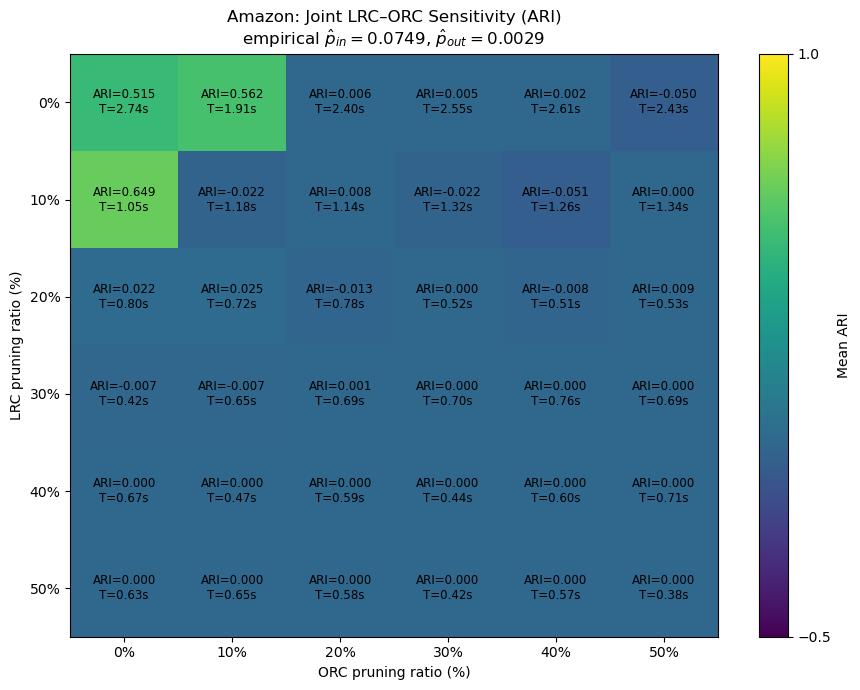

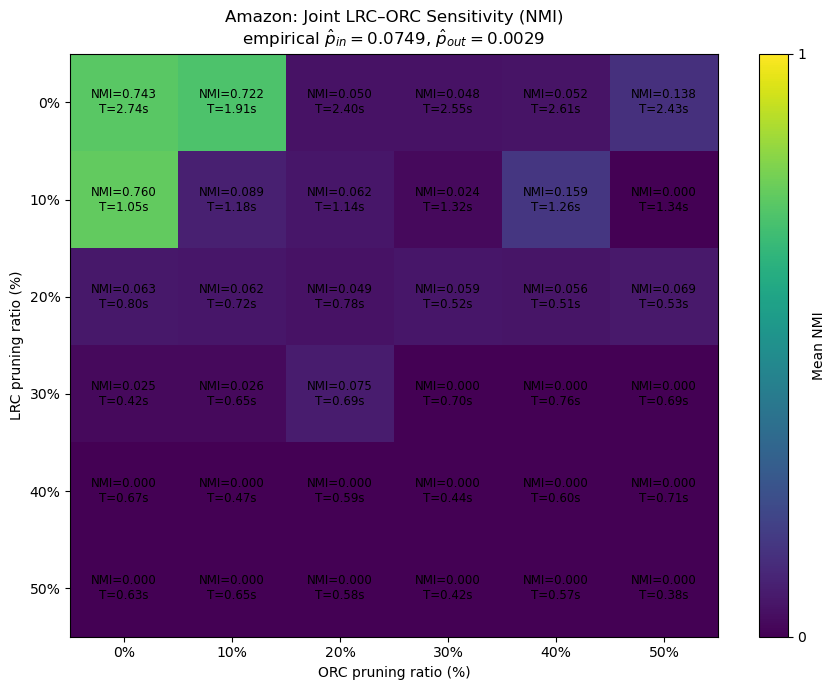


Saved:
  amazon_ari_lrc_orc_heatmap_with_runtime.png
  amazon_nmi_lrc_orc_heatmap_with_runtime.png
  amazon_lrc_orc_heatmap_summary.csv
  amazon_lrc_orc_heatmap_raw.csv
  amazon_empirical_pin_pout.csv


In [32]:
# ============================================================
# AMAZON: JOINT LRC-ORC PRUNING HEATMAPS
# Each cell shows accuracy + runtime
# p_in and p_out are estimated from the actual Amazon benchmark
# ============================================================

import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 0. OUTPUT DIRECTORY
# ------------------------------------------------------------

OUTPUT_DIR = Path("./amazon_heatmaps")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. ESTIMATE EMPIRICAL p_in AND p_out FROM AMAZON
# ============================================================

def estimate_empirical_pin_pout(
    graph,
    label_attribute="label_gt",
):
    """
    Estimate SBM-style within-label and between-label edge
    probabilities directly from the observed labeled graph.

    p_in  = observed within-label edges /
            possible within-label node pairs

    p_out = observed between-label edges /
            possible between-label node pairs
    """

    labeled_nodes = [
        node
        for node in graph.nodes()
        if label_attribute in graph.nodes[node]
    ]

    labels = {
        node: graph.nodes[node][label_attribute]
        for node in labeled_nodes
    }

    label_counts = (
        pd.Series(list(labels.values()))
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Possible within-label pairs
    # --------------------------------------------------------

    possible_within = sum(
        n * (n - 1) / 2
        for n in label_counts.values()
    )

    total_nodes = len(labeled_nodes)

    possible_total = (
        total_nodes
        * (total_nodes - 1)
        / 2
    )

    possible_between = (
        possible_total
        - possible_within
    )

    # --------------------------------------------------------
    # Count observed within/between edges
    # --------------------------------------------------------

    observed_within = 0
    observed_between = 0

    labeled_set = set(
        labeled_nodes
    )

    for u, v in graph.edges():

        if (
            u not in labeled_set
            or v not in labeled_set
        ):
            continue

        if labels[u] == labels[v]:
            observed_within += 1
        else:
            observed_between += 1

    p_in_hat = (
        observed_within / possible_within
        if possible_within > 0
        else np.nan
    )

    p_out_hat = (
        observed_between / possible_between
        if possible_between > 0
        else np.nan
    )

    return {
        "p_in": p_in_hat,
        "p_out": p_out_hat,

        "observed_within_edges":
            observed_within,

        "observed_between_edges":
            observed_between,

        "possible_within_pairs":
            possible_within,

        "possible_between_pairs":
            possible_between,

        "n_labeled":
            total_nodes,

        "n_labels":
            len(label_counts),
    }


amazon_structure = (
    estimate_empirical_pin_pout(
        H,
        label_attribute="label_gt",
    )
)


AMAZON_PIN = (
    amazon_structure["p_in"]
)

AMAZON_POUT = (
    amazon_structure["p_out"]
)


print("=" * 70)
print("AMAZON EMPIRICAL STRUCTURE")
print("=" * 70)

print(
    f"Nodes       : "
    f"{amazon_structure['n_labeled']}"
)

print(
    f"Labels      : "
    f"{amazon_structure['n_labels']}"
)

print(
    f"Within edges: "
    f"{amazon_structure['observed_within_edges']}"
)

print(
    f"Between edges: "
    f"{amazon_structure['observed_between_edges']}"
)

print(
    f"Estimated p_in  = "
    f"{AMAZON_PIN:.6f}"
)

print(
    f"Estimated p_out = "
    f"{AMAZON_POUT:.6f}"
)


# ============================================================
# 2. HEATMAP SETTINGS
# ============================================================

LRC_HEAT_VALUES = [
    0,
    10,
    20,
    30,
    40,
    50,
]

ORC_HEAT_VALUES = [
    0,
    10,
    20,
    30,
    40,
    50,
]

HEATMAP_ALPHA = 0.5


# Same style as your existing Amazon multi-seed experiment
HEATMAP_SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


print("\n" + "=" * 70)
print("AMAZON JOINT LRC-ORC SENSITIVITY")
print("=" * 70)

print(
    "LRC values:",
    LRC_HEAT_VALUES,
)

print(
    "ORC values:",
    ORC_HEAT_VALUES,
)

print(
    "alpha:",
    HEATMAP_ALPHA,
)

print(
    "seeds:",
    HEATMAP_SEEDS,
)


# ============================================================
# 3. RUN ALL PRUNING CONFIGURATIONS
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print(
            f"\nRunning "
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )

        # ----------------------------------------------------
        # Prepare Combo graph ONCE per pruning configuration
        # ----------------------------------------------------

        try:

            combo_info_heat = (
                cdu.prepare_combo_graph(
                    graph=H,
                    lrc_pct=lrc_pct,
                    orc_pct=orc_pct,
                    alpha=HEATMAP_ALPHA,
                    iterations=ORC_ITERATIONS,
                    method="Sinkhorn",
                    weight="weight",
                )
            )

        except Exception as error:

            print(
                "Preparation failed:",
                repr(error),
            )

            for seed in HEATMAP_SEEDS:

                heatmap_rows.append(
                    {
                        "seed": seed,

                        "lrc_pct":
                            lrc_pct,

                        "orc_pct":
                            orc_pct,

                        "alpha":
                            HEATMAP_ALPHA,

                        "p_in":
                            AMAZON_PIN,

                        "p_out":
                            AMAZON_POUT,

                        "ARI":
                            np.nan,

                        "NMI":
                            np.nan,

                        "Runtime":
                            np.nan,

                        "Prep_time":
                            np.nan,

                        "Community_time":
                            np.nan,

                        "V":
                            np.nan,

                        "E":
                            np.nan,

                        "status":
                            "failed",
                    }
                )

            continue

        # ----------------------------------------------------
        # Community-detection evaluation across seeds
        # ----------------------------------------------------

        for seed in HEATMAP_SEEDS:

            result = (
                cdu.evaluate_prepared_graph(
                    info=combo_info_heat,
                    algorithm="louvain",
                    seed=seed,
                    weight="weight",
                    label_attribute="label_gt",
                )
            )

            heatmap_rows.append(
                {
                    "seed":
                        seed,

                    "lrc_pct":
                        lrc_pct,

                    "orc_pct":
                        orc_pct,

                    "alpha":
                        HEATMAP_ALPHA,

                    "p_in":
                        AMAZON_PIN,

                    "p_out":
                        AMAZON_POUT,

                    "ARI":
                        result["ARI"],

                    "NMI":
                        result["NMI"],

                    "Runtime":
                        result["runtime_sec"],

                    "Prep_time":
                        result["prep_time"],

                    "Community_time":
                        result[
                            "community_time"
                        ],

                    "V":
                        result["V"],

                    "E":
                        result["E"],

                    "status":
                        "ok",
                }
            )


df_amazon_heatmap_raw = (
    pd.DataFrame(
        heatmap_rows
    )
)


# ============================================================
# 4. SUMMARY ACROSS SEEDS
# ============================================================

df_amazon_heatmap_valid = (
    df_amazon_heatmap_raw[
        df_amazon_heatmap_raw[
            "status"
        ] == "ok"
    ]
    .copy()
)


amazon_heatmap_summary = (
    df_amazon_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean",
        ),

        ARI_std=(
            "ARI",
            "std",
        ),

        NMI_mean=(
            "NMI",
            "mean",
        ),

        NMI_std=(
            "NMI",
            "std",
        ),

        Runtime_mean=(
            "Runtime",
            "mean",
        ),

        Runtime_std=(
            "Runtime",
            "std",
        ),

        Prep_time_mean=(
            "Prep_time",
            "mean",
        ),

        Community_time_mean=(
            "Community_time",
            "mean",
        ),

        V_mean=(
            "V",
            "mean",
        ),

        E_mean=(
            "E",
            "mean",
        ),
    )
)


print(
    "\nAmazon joint sensitivity summary:"
)

display(
    amazon_heatmap_summary
)


# ============================================================
# 5. CREATE HEATMAP MATRICES
# ============================================================

def make_matrix(
    dataframe,
    value_column,
):

    return (
        dataframe
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=value_column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = make_matrix(
    amazon_heatmap_summary,
    "ARI_mean",
)

nmi_matrix = make_matrix(
    amazon_heatmap_summary,
    "NMI_mean",
)

runtime_matrix = make_matrix(
    amazon_heatmap_summary,
    "Runtime_mean",
)


# ============================================================
# 6. PLOT FUNCTION:
#    COLOR = ACCURACY
#    TEXT  = ACCURACY + TIME
# ============================================================

def plot_amazon_metric_heatmap(
    metric_matrix,
    runtime_matrix,
    metric_name,
):

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    # --------------------------------------------------------
    # Metric-specific color scale
    # ARI: -0.5 to 1
    # NMI:  0 to 1
    # --------------------------------------------------------

    if metric_name == "ARI":

        vmin = -0.5
        vmax = 1.0

        colorbar_ticks = [
            -0.5,
            1.0,
        ]

    elif metric_name == "NMI":

        vmin = 0.0
        vmax = 1.0

        colorbar_ticks = [
            0.0,
            1.0,
        ]

    else:

        vmin = None
        vmax = None
        colorbar_ticks = None

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    im = ax.imshow(
        metric_matrix.values,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )


    ax.set_xticks(
        np.arange(
            len(
                ORC_HEAT_VALUES
            )
        )
    )

    ax.set_xticklabels(
        [
            f"{value}%"
            for value
            in ORC_HEAT_VALUES
        ]
    )


    ax.set_yticks(
        np.arange(
            len(
                LRC_HEAT_VALUES
            )
        )
    )

    ax.set_yticklabels(
        [
            f"{value}%"
            for value
            in LRC_HEAT_VALUES
        ]
    )


    ax.set_xlabel(
        "ORC pruning ratio (%)"
    )

    ax.set_ylabel(
        "LRC pruning ratio (%)"
    )


    ax.set_title(
        f"Amazon: Joint LRC–ORC Sensitivity ({metric_name})\n"
        f"empirical "
        f"$\\hat{{p}}_{{in}}={AMAZON_PIN:.4f}$, "
        f"$\\hat{{p}}_{{out}}={AMAZON_POUT:.4f}$"
    )


    # --------------------------------------------------------
    # Put metric AND runtime inside every cell
    # --------------------------------------------------------

    for i, lrc_pct in enumerate(
        LRC_HEAT_VALUES
    ):

        for j, orc_pct in enumerate(
            ORC_HEAT_VALUES
        ):

            metric_value = (
                metric_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )

            runtime_value = (
                runtime_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )


            if (
                pd.isna(metric_value)
                or pd.isna(runtime_value)
            ):

                text = "failed"

            else:

                text = (
                    f"{metric_name}="
                    f"{metric_value:.3f}\n"
                    f"T="
                    f"{runtime_value:.2f}s"
                )


            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8.5,
            )


    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
    )

    if colorbar_ticks is not None:

        cbar.set_ticks(
            colorbar_ticks
        )

    cbar.set_label(
        f"Mean {metric_name}"
    )


    fig.tight_layout()

    return fig


# ============================================================
# 7. ARI HEATMAP
# ============================================================

fig_ari = (
    plot_amazon_metric_heatmap(
        metric_matrix=
            ari_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "ARI",
    )
)

plt.show()


# ============================================================
# 8. NMI HEATMAP
# ============================================================

fig_nmi = (
    plot_amazon_metric_heatmap(
        metric_matrix=
            nmi_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "NMI",
    )
)

plt.show()


# ============================================================
# 9. SAVE FIGURES + TABLES
# ============================================================

fig_ari.savefig(
    OUTPUT_DIR
    / "amazon_ari_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)

fig_nmi.savefig(
    OUTPUT_DIR
    / "amazon_nmi_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


amazon_heatmap_summary.to_csv(
    OUTPUT_DIR
    / "amazon_lrc_orc_heatmap_summary.csv",
    index=False,
)

df_amazon_heatmap_raw.to_csv(
    OUTPUT_DIR
    / "amazon_lrc_orc_heatmap_raw.csv",
    index=False,
)


# Save estimated structure too
pd.DataFrame(
    [amazon_structure]
).to_csv(
    OUTPUT_DIR
    / "amazon_empirical_pin_pout.csv",
    index=False,
)


plt.close(
    fig_ari
)

plt.close(
    fig_nmi
)


print("\nSaved:")

print(
    "  amazon_ari_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  amazon_nmi_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  amazon_lrc_orc_heatmap_summary.csv"
)

print(
    "  amazon_lrc_orc_heatmap_raw.csv"
)

print(
    "  amazon_empirical_pin_pout.csv"
)


Amazon
empirical p_in  = 0.074876
empirical p_out = 0.002906

Amazon | LRC=0% | ORC=0%
seed=0 | ARI=0.515 | NMI=0.743 | T=4.14s
seed=1 | ARI=0.515 | NMI=0.743 | T=4.14s

Amazon | LRC=0% | ORC=5%
seed=0 | ARI=0.519 | NMI=0.751 | T=3.63s
seed=1 | ARI=0.519 | NMI=0.751 | T=3.64s

Amazon | LRC=0% | ORC=10%
seed=0 | ARI=0.562 | NMI=0.722 | T=3.80s
seed=1 | ARI=0.562 | NMI=0.722 | T=3.80s

Amazon | LRC=0% | ORC=20%
seed=0 | ARI=0.002 | NMI=0.047 | T=3.54s
seed=1 | ARI=-0.008 | NMI=0.037 | T=3.55s

Amazon | LRC=0% | ORC=30%
seed=0 | ARI=0.013 | NMI=0.054 | T=4.23s
seed=1 | ARI=0.013 | NMI=0.054 | T=4.23s

Amazon | LRC=5% | ORC=0%
seed=0 | ARI=0.605 | NMI=0.772 | T=2.63s
seed=1 | ARI=0.605 | NMI=0.772 | T=2.63s

Amazon | LRC=5% | ORC=5%
seed=0 | ARI=0.547 | NMI=0.701 | T=2.98s
seed=1 | ARI=0.566 | NMI=0.726 | T=2.99s

Amazon | LRC=5% | ORC=10%
seed=0 | ARI=-0.021 | NMI=0.075 | T=3.19s
seed=1 | ARI=0.078 | NMI=0.172 | T=3.19s

Amazon | LRC=5% | ORC=20%
seed=0 | ARI=-0.004 | NMI=0.037 | T=3.61s

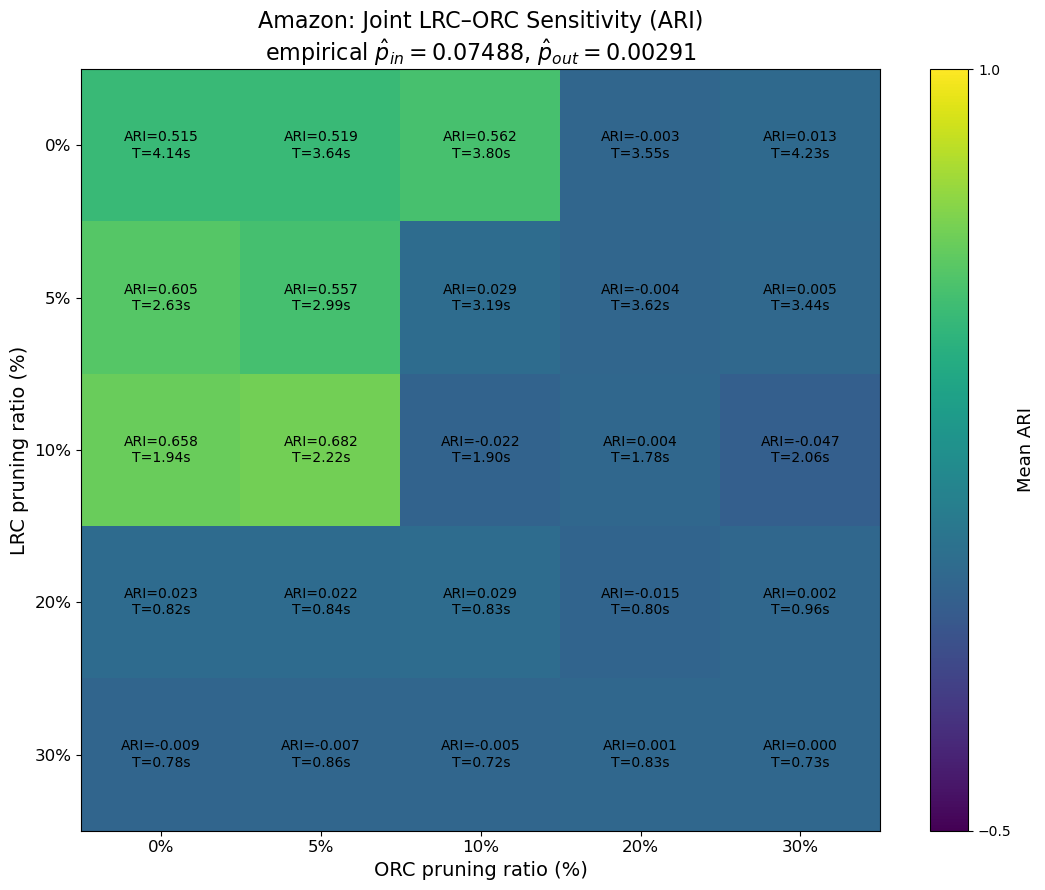

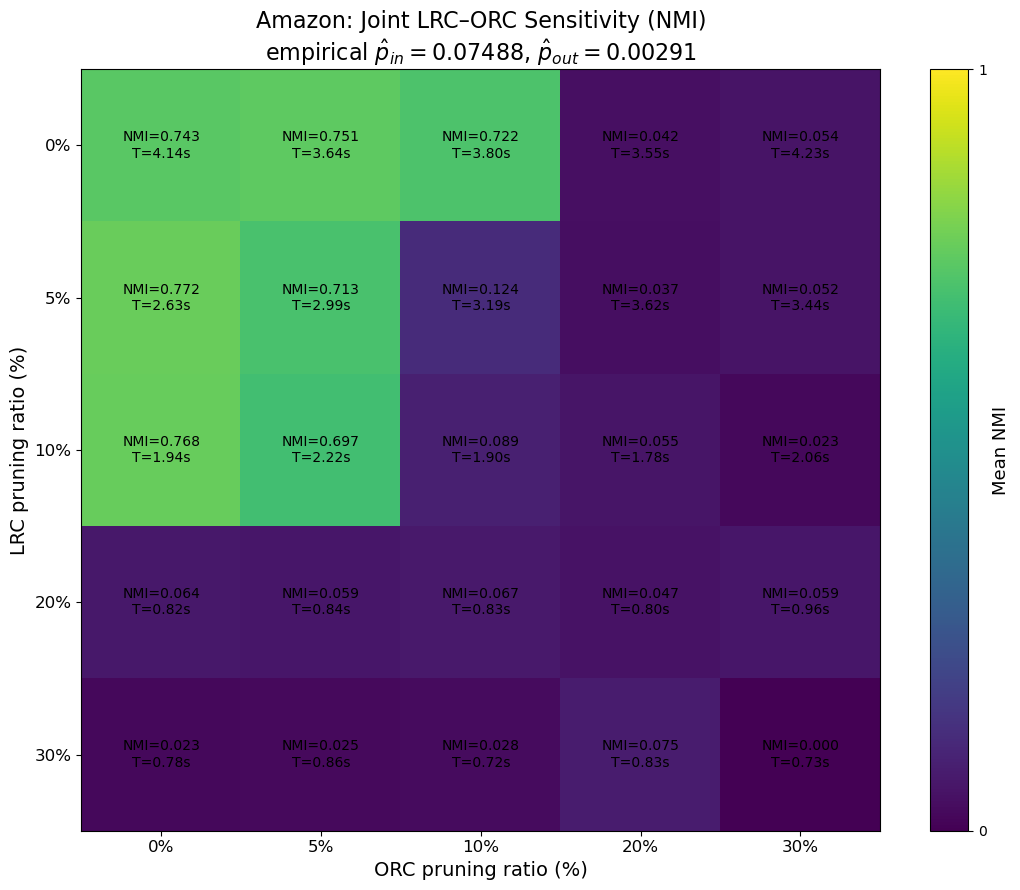

In [34]:
import importlib
import community_detection_utils as cdu

importlib.reload(cdu)
amazon_raw, amazon_summary = cdu.run_real_dataset_heatmap(
    H,
    "Amazon",
    orc_iterations=5
)